# FAILSAFE : Data Preprocessing & Feature Engineering

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

In [15]:
df = pd.read_csv('../data/processed/students_combined.csv')

print(f'Loaded: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'\nTarget distribution:')
print(df['at_risk'].value_counts())
print(f'\nColumn types:')
print(df.dtypes.value_counts())

Loaded: 1044 rows, 35 columns

Target distribution:
at_risk
0    814
1    230
Name: count, dtype: int64

Column types:
str      18
int64    17
Name: count, dtype: int64


In [16]:
y = df['at_risk'].copy()

# Drop columns that would cause data leakage or aren't useful
# G3 = final grade (target was derived from this — must drop)
# subject = just math/portuguese label, not a real student attribute
cols_to_drop = ['G3', 'at_risk', 'subject']

X = df.drop(columns=cols_to_drop)

print(f'Features shape: {X.shape}')
print(f'Target shape:   {y.shape}')
print(f'\nFeatures kept:')
print(list(X.columns))

Features shape: (1044, 32)
Target shape:   (1044,)

Features kept:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']


In [17]:
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

print(f'Categorical columns ({len(categorical_cols)}):')
for col in categorical_cols:
    unique_vals = X[col].unique()
    print(f'  {col}: {unique_vals}')

print(f'\nNumeric columns ({len(numeric_cols)}):')
print(numeric_cols)

Categorical columns (17):
  school: <StringArray>
['GP', 'MS']
Length: 2, dtype: str
  sex: <StringArray>
['F', 'M']
Length: 2, dtype: str
  address: <StringArray>
['U', 'R']
Length: 2, dtype: str
  famsize: <StringArray>
['GT3', 'LE3']
Length: 2, dtype: str
  Pstatus: <StringArray>
['A', 'T']
Length: 2, dtype: str
  Mjob: <StringArray>
['at_home', 'health', 'other', 'services', 'teacher']
Length: 5, dtype: str
  Fjob: <StringArray>
['teacher', 'other', 'services', 'health', 'at_home']
Length: 5, dtype: str
  reason: <StringArray>
['course', 'other', 'home', 'reputation']
Length: 4, dtype: str
  guardian: <StringArray>
['mother', 'father', 'other']
Length: 3, dtype: str
  schoolsup: <StringArray>
['yes', 'no']
Length: 2, dtype: str
  famsup: <StringArray>
['no', 'yes']
Length: 2, dtype: str
  paid: <StringArray>
['no', 'yes']
Length: 2, dtype: str
  activities: <StringArray>
['no', 'yes']
Length: 2, dtype: str
  nursery: <StringArray>
['yes', 'no']
Length: 2, dtype: str
  higher: <Stri

In [18]:
X_encoded = X.copy()
label_encoders = {}  

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    label_encoders[col] = le
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'{col}: {mapping}')

print(f'\nEncoding complete! All columns are now numeric.')
print(f'DataFrame dtype counts: {X_encoded.dtypes.value_counts().to_dict()}')

school: {'GP': np.int64(0), 'MS': np.int64(1)}
sex: {'F': np.int64(0), 'M': np.int64(1)}
address: {'R': np.int64(0), 'U': np.int64(1)}
famsize: {'GT3': np.int64(0), 'LE3': np.int64(1)}
Pstatus: {'A': np.int64(0), 'T': np.int64(1)}
Mjob: {'at_home': np.int64(0), 'health': np.int64(1), 'other': np.int64(2), 'services': np.int64(3), 'teacher': np.int64(4)}
Fjob: {'at_home': np.int64(0), 'health': np.int64(1), 'other': np.int64(2), 'services': np.int64(3), 'teacher': np.int64(4)}
reason: {'course': np.int64(0), 'home': np.int64(1), 'other': np.int64(2), 'reputation': np.int64(3)}
guardian: {'father': np.int64(0), 'mother': np.int64(1), 'other': np.int64(2)}
schoolsup: {'no': np.int64(0), 'yes': np.int64(1)}
famsup: {'no': np.int64(0), 'yes': np.int64(1)}
paid: {'no': np.int64(0), 'yes': np.int64(1)}
activities: {'no': np.int64(0), 'yes': np.int64(1)}
nursery: {'no': np.int64(0), 'yes': np.int64(1)}
higher: {'no': np.int64(0), 'yes': np.int64(1)}
internet: {'no': np.int64(0), 'yes': np.int6

## Feature Engineering

In [6]:
X_feat = X_encoded.copy()

# 1. Grade trend: is the student improving or declining?
#    Positive = improving (G2 better than G1), Negative = declining
if 'G1' in X_feat.columns and 'G2' in X_feat.columns:
    X_feat['grade_trend'] = X_feat['G2'] - X_feat['G1']
    print('Created: grade_trend (G2 - G1)')

# 2. Average of G1 and G2 (overall mid-semester performance)
if 'G1' in X_feat.columns and 'G2' in X_feat.columns:
    X_feat['avg_grade'] = (X_feat['G1'] + X_feat['G2']) / 2
    print('Created: avg_grade ((G1 + G2) / 2)')

# 3. Study efficiency: study time relative to absences
#    High study time but also high absences = inconsistent student
X_feat['study_efficiency'] = X_feat['studytime'] / (X_feat['absences'] + 1)
print('Created: study_efficiency (studytime / (absences + 1))')

# 4. Social risk score: going out + alcohol use (combined lifestyle risk)
X_feat['social_risk'] = X_feat['goout'] + X_feat['Dalc'] + X_feat['Walc']
print('Created: social_risk (goout + Dalc + Walc)')

# 5. Support score: has school support + family support + paid classes
X_feat['support_score'] = X_feat['schoolsup'] + X_feat['famsup'] + X_feat['paid']
print('Created: support_score (schoolsup + famsup + paid)')

# 6. Parental education average
X_feat['parent_edu'] = (X_feat['Medu'] + X_feat['Fedu']) / 2
print('Created: parent_edu ((Medu + Fedu) / 2)')

print(f'\nTotal features after engineering: {X_feat.shape[1]}')

Created: grade_trend (G2 - G1)
Created: avg_grade ((G1 + G2) / 2)
Created: study_efficiency (studytime / (absences + 1))
Created: social_risk (goout + Dalc + Walc)
Created: support_score (schoolsup + famsup + paid)
Created: parent_edu ((Medu + Fedu) / 2)

Total features after engineering: 38


## Visualise 

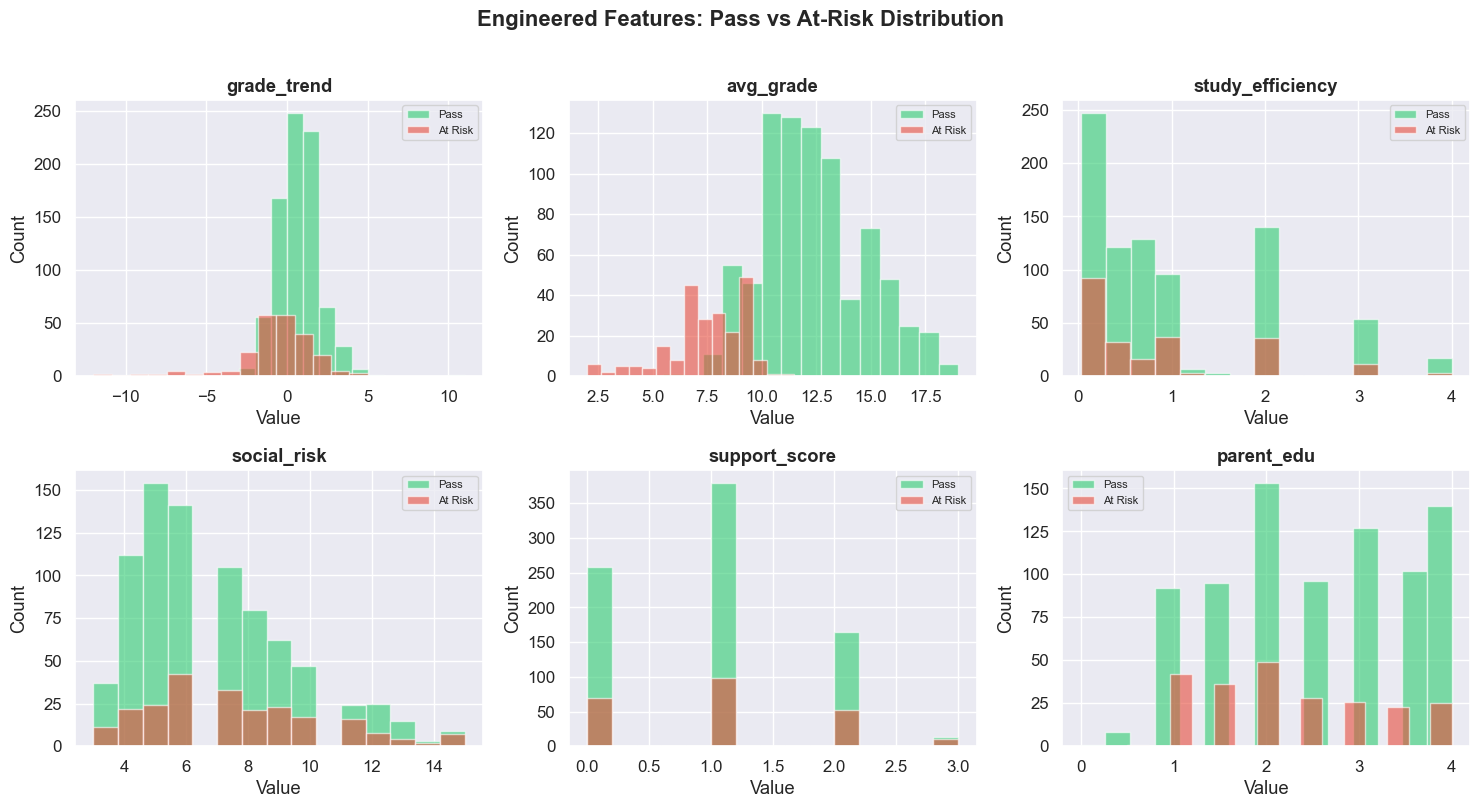

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

new_features = ['grade_trend', 'avg_grade', 'study_efficiency',
                'social_risk', 'support_score', 'parent_edu']

for i, feat in enumerate(new_features):
    if feat in X_feat.columns:
        for risk_val, color, label in [(0, '#2ecc71', 'Pass'), (1, '#e74c3c', 'At Risk')]:
            mask = y == risk_val
            axes[i].hist(X_feat[mask][feat], bins=15, alpha=0.6,
                        color=color, label=label, edgecolor='white')
        axes[i].set_title(f'{feat}', fontweight='bold')
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Count')
        axes[i].legend(fontsize=8)

plt.suptitle('Engineered Features: Pass vs At-Risk Distribution', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/07_engineered_features.png', bbox_inches='tight')
plt.show()

## Scale numeric features

Features have very different ranges:
- absences: 0 to 75
- studytime: 1 to 4
- age: 15 to 22


In [23]:
scaler = StandardScaler()

# Scale all features
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_feat),
    columns=X_feat.columns
)

print('Before scaling (absences column):')
print(f'  Mean: {X_feat["absences"].mean():.2f}, Std: {X_feat["absences"].std():.2f}')
print(f'  Min:  {X_feat["absences"].min():.2f}, Max: {X_feat["absences"].max():.2f}')

print('\nAfter scaling (absences column):')
print(f'  Mean: {X_scaled["absences"].mean():.2f}, Std: {X_scaled["absences"].std():.2f}')
print(f'  Min:  {X_scaled["absences"].min():.2f}, Max: {X_scaled["absences"].max():.2f}')


Before scaling (absences column):
  Mean: 4.43, Std: 6.21
  Min:  0.00, Max: 75.00

After scaling (absences column):
  Mean: -0.00, Std: 1.00
  Min:  -0.71, Max: 11.37


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,      
    stratify=y           
)

print(f'Training set:   {X_train.shape[0]} students ({X_train.shape[0]/len(X_scaled)*100:.0f}%)')
print(f'Test set:       {X_test.shape[0]} students ({X_test.shape[0]/len(X_scaled)*100:.0f}%)')

print(f'\nTraining set class distribution:')
print(y_train.value_counts())
print(f'\nTest set class distribution:')
print(y_test.value_counts())

Training set:   835 students (80%)
Test set:       209 students (20%)

Training set class distribution:
at_risk
0    651
1    184
Name: count, dtype: int64

Test set class distribution:
at_risk
0    163
1     46
Name: count, dtype: int64


## Cell 10 — Apply SMOTE to fix class imbalance

SMOTE = Synthetic Minority Oversampling TEchnique

Problem: 78% pass vs 22% at-risk. The model will be biased toward predicting 'pass'
because that's the majority class — it's the easy answer.

SMOTE solution: Create synthetic (artificial but realistic) at-risk students
by interpolating between existing at-risk students. This balances the classes
WITHOUT simply duplicating rows.

IMPORTANT: SMOTE is applied ONLY to training data, never to test data.
The test set must reflect real-world distribution.

Before SMOTE:
  Training samples: 835
  Pass (0): 651, At-risk (1): 184

After SMOTE:
  Training samples: 1302
  Pass (0): 651, At-risk (1): 651
  Balance ratio: 1.0:1


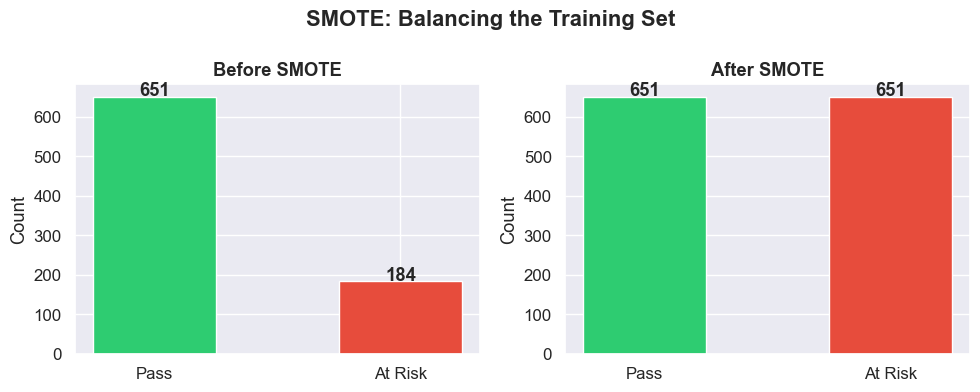

In [10]:
print('Before SMOTE:')
print(f'  Training samples: {len(X_train)}')
print(f'  Pass (0): {sum(y_train==0)}, At-risk (1): {sum(y_train==1)}')

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print('\nAfter SMOTE:')
print(f'  Training samples: {len(X_train_balanced)}')
print(f'  Pass (0): {sum(y_train_balanced==0)}, At-risk (1): {sum(y_train_balanced==1)}')
print(f'  Balance ratio: {sum(y_train_balanced==0)/sum(y_train_balanced==1):.1f}:1')

# Visualise before/after
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(['Pass', 'At Risk'], [sum(y_train==0), sum(y_train==1)],
            color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Before SMOTE', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([sum(y_train==0), sum(y_train==1)]):
    axes[0].text(i, v+2, str(v), ha='center', fontweight='bold')

axes[1].bar(['Pass', 'At Risk'], [sum(y_train_balanced==0), sum(y_train_balanced==1)],
            color=colors, edgecolor='white', width=0.5)
axes[1].set_title('After SMOTE', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate([sum(y_train_balanced==0), sum(y_train_balanced==1)]):
    axes[1].text(i, v+2, str(v), ha='center', fontweight='bold')

plt.suptitle('SMOTE: Balancing the Training Set', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/08_smote_balancing.png', bbox_inches='tight')
plt.show()

## Cell 11 — Save everything for Step 4

In [13]:
os.makedirs('../data/processed', exist_ok=True)

# Save train/test splits
X_train_balanced.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
pd.Series(y_train_balanced, name='at_risk').to_csv('../data/processed/y_train.csv', index=False)
pd.Series(y_test, name='at_risk').to_csv('../data/processed/y_test.csv', index=False)

# Save feature names for later
feature_names = list(X_feat.columns)
pd.Series(feature_names).to_csv('../data/processed/feature_names.csv', index=False)

# Save the scaler and encoders — needed to transform new data at prediction time
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(label_encoders, '../models/label_encoders.pkl')

print('Saved files:')
print('  data/processed/X_train.csv       (balanced training features)')
print('  data/processed/X_test.csv        (test features)')
print('  data/processed/y_train.csv       (balanced training labels)')
print('  data/processed/y_test.csv        (test labels)')
print('  data/processed/feature_names.csv (column names)')
print('  models/scaler.pkl                (StandardScaler)')
print('  models/label_encoders.pkl        (LabelEncoders)')

print(f'\n--- PREPROCESSING COMPLETE ---')
print(f'Training set: {X_train_balanced.shape[0]} samples, {X_train_balanced.shape[1]} features')
print(f'Test set:     {X_test.shape[0]} samples, {X_test.shape[1]} features')
print(f'\nReady for Step 4: Model Training!')

Saved files:
  data/processed/X_train.csv       (balanced training features)
  data/processed/X_test.csv        (test features)
  data/processed/y_train.csv       (balanced training labels)
  data/processed/y_test.csv        (test labels)
  data/processed/feature_names.csv (column names)
  models/scaler.pkl                (StandardScaler)
  models/label_encoders.pkl        (LabelEncoders)

--- PREPROCESSING COMPLETE ---
Training set: 1302 samples, 38 features
Test set:     209 samples, 38 features

Ready for Step 4: Model Training!
